**Problem Definition:**

**Input Representation:**

The input is a photograph of a leaf, taken from a smartphone or camera.
Before feeding it to the model, the image is:

1. Resized to 64 × 64 pixels

2. Converted to 3 colour channels (Red, Green, Blue)

3. Each pixel value is scaled from 0–255 down to 0–1 (called normalisation)

So the model sees the image as a 64 × 64 × 3 grid of numbers

**Expected Output:**

The model outputs a probability for each of the 5 classes.

**Type of Learning Task:**

This is supervised multi-class classification.

1. Supervised means the model is trained on labelled examples where each image already has a correct answer attached to it (e.g. "this leaf has Early Blight").

2. Multi-class means there are more than 2 possible answers (we have 5 classes).

3. Classification means the output is a category, not a number or a sequence.

**Real-World Relevance:**

India is one of the largest producers of tomatoes and potatoes in the world. But crop diseases can wipe out an entire harvest if not caught early.

**The problem:** A farmer notices something wrong with their plants. To get a proper diagnosis, they would need to visit an agricultural expert or send leaf samples to a lab which takes days and costs money. More than 86% of Indian farmers are small-scale farmers who simply don't have access to this kind of expert help.

**What our model does:** The farmer just takes a photo of the affected leaf on their phone, uploads it, and gets an answer in seconds for free, from anywhere. No expert needed.

**The scale of the problem:** India loses approximately ₹50,000 crore every year to crop diseases. Early and accurate detection means:

1. Farmers can apply the right treatment before the disease spreads
2. Less wasted pesticide (saving money and reducing environmental damage)
3. More of the harvest is saved

This is exactly the kind of problem where deep learning is genuinely useful.The disease shows up as visible patterns on the leaf (spots, discolouration, lesions), and a CNN is specifically designed to detect these kinds of visual patterns.

**Implementation:**

**1. Installing libraries**

In [27]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'gradio==4.44.0', 'kaggle', 'tensorflow'], check=False)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'gradio==4.44.0', 'kaggle', 'tensorflow'], returncode=0)

**2. Uploading kaggle api key**

In [28]:
import os, subprocess
from google.colab import files
os.makedirs('/root/.kaggle', exist_ok=True)
uploaded = files.upload()
for fname in uploaded.keys():
    dest = '/root/.kaggle/kaggle.json'
    with open(dest, 'wb') as f:
        f.write(uploaded[fname])
    os.chmod(dest, 0o600)
    print(f'kaggle.json installed at {dest}')

Saving kaggle.json to kaggle (1).json
kaggle.json installed at /root/.kaggle/kaggle.json


**3. Downloading dataset:**

In [29]:
os.makedirs('/content/data', exist_ok=True)
result = subprocess.run([
    'kaggle', 'datasets', 'download',
    '-d', 'vipoooool/new-plant-diseases-dataset',
    '-p', '/content/data/', '--unzip'
], capture_output=True, text=True)
if result.returncode == 0:
    print('Dataset downloaded and unzipped successfully')
else:
    print('Kaggle download failed.')
    print(result.stderr)

Dataset downloaded and unzipped successfully


Here we picked the five most relevant classes for Indian farming context and randomly copied 500 images per class which gave us 2500 images in total

In [30]:
import os, shutil, random
def find_class_folder(base='/content/data', min_classes=15):
    for root, dirs, files in os.walk(base):
        dirs_with_images = [
            d for d in dirs
            if len([f for f in os.listdir(os.path.join(root, d))
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) > 10
        ]
        if len(dirs_with_images) >= min_classes:
            return root, sorted(dirs_with_images)
    return None, []

FULL_DATA_DIR, all_classes = find_class_folder()

if FULL_DATA_DIR is None:
    for item in os.listdir('/content/data'):
        print(f'  {item}')
    print()
    print('Manually set FULL_DATA_DIR below and re-run this cell.')
    FULL_DATA_DIR = '/content/data/CHANGE_THIS'
else:
    print(f'Data folder: {FULL_DATA_DIR}')
    print(f'Total classes: {len(all_classes)}')
    print(f'Preview: {all_classes[:5]}')

WANTED = [
    'Tomato___healthy',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Potato___Early_blight',
    'Potato___healthy',
]

SELECTED = [c for c in WANTED if c in all_classes]
if len(SELECTED) < 3:
    print('\nPreferred classes not found. Using first 5 available:')
    SELECTED = all_classes[:5]

print(f'\nSelected {len(SELECTED)} classes:')
for cls in SELECTED:
    n = len([f for f in os.listdir(os.path.join(FULL_DATA_DIR, cls))
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f'   {cls}: {n} images available')

SUBSET_DIR       = '/content/data/subset'
IMAGES_PER_CLASS = 500

if os.path.exists(SUBSET_DIR):
    shutil.rmtree(SUBSET_DIR)
os.makedirs(SUBSET_DIR)

random.seed(42)
for cls in SELECTED:
    src = os.path.join(FULL_DATA_DIR, cls)
    dst = os.path.join(SUBSET_DIR, cls)
    os.makedirs(dst, exist_ok=True)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)
    for img in imgs[:IMAGES_PER_CLASS]:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))
    print(f' {cls}: {min(len(imgs), IMAGES_PER_CLASS)} images copied')

total = sum(len(os.listdir(os.path.join(SUBSET_DIR, c))) for c in SELECTED)
print(f'\nSubset ready — {len(SELECTED)} classes, {total} images total')
print(f'Location: {SUBSET_DIR}')

Data folder: /content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Total classes: 38
Preview: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Selected 5 classes:
   Tomato___healthy: 1926 images available
   Tomato___Early_blight: 1920 images available
   Tomato___Late_blight: 1851 images available
   Potato___Early_blight: 1939 images available
   Potato___healthy: 1824 images available
 Tomato___healthy: 500 images copied
 Tomato___Early_blight: 500 images copied
 Tomato___Late_blight: 500 images copied
 Potato___Early_blight: 500 images copied
 Potato___healthy: 500 images copied

Subset ready — 5 classes, 2500 images total
Location: /content/data/subset


In [31]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

Here we are resizing all images to 64*64 pixels and setting batch sie to 32

In [32]:
IMG_SIZE    = 64
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = len(SELECTED)
print('Hyperparameters:')
print(f'  Image size  : {IMG_SIZE}×{IMG_SIZE}×3')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Max epochs  : {EPOCHS}  (EarlyStopping patience=5)')
print(f'  Num classes : {NUM_CLASSES}')
print(f'  GPU active  : {bool(tf.config.list_physical_devices("GPU"))}')

Hyperparameters:
  Image size  : 64×64×3
  Batch size  : 32
  Max epochs  : 20  (EarlyStopping patience=5)
  Num classes : 5
  GPU active  : True


Preprocessing:

Here we are doing normalization i.e converting every pixel from 0-255 down to 0-1

We are also doing data augumentation so same image cannot be seen twice which helps reduce overfitting.

In [33]:
def make_generators(subset_dir):
    datagen = ImageDataGenerator(
        rescale            = 1.0 / 255,
        validation_split   = 0.2,
        rotation_range     = 20,
        width_shift_range  = 0.1,
        height_shift_range = 0.1,
        horizontal_flip    = True,
        zoom_range         = 0.15,
    )
    train_gen = datagen.flow_from_directory(
        subset_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training', seed=42, shuffle=True,
    )
    val_gen = datagen.flow_from_directory(
        subset_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation', seed=42, shuffle=False,
    )
    return train_gen, val_gen

In [34]:
train_gen, val_gen = make_generators(SUBSET_DIR)

CLASS_MAP = {str(v): k for k, v in train_gen.class_indices.items()}
with open('/content/class_indices.json', 'w') as f:
    json.dump(CLASS_MAP, f)

print('\nClass index mapping:')
for idx, name in CLASS_MAP.items():
    print(f'  {idx} → {name}')

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.

Class index mapping:
  0 → Potato___Early_blight
  1 → Potato___healthy
  2 → Tomato___Early_blight
  3 → Tomato___Late_blight
  4 → Tomato___healthy


**CNN architecture:**

In [35]:
def build_cnn(num_classes, with_dropout=True, dropout_rate=0.5):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = inp

    for n_filters in [32, 64, 128, 256]:
        x = layers.Conv2D(n_filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)

    if with_dropout:
        x = layers.Dropout(rate=dropout_rate)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out)
    return model

In [36]:
print('\n' + '='*60)
print('CNN Architecture Summary (with Dropout):')
print('='*60)
sample = build_cnn(NUM_CLASSES, with_dropout=True)
sample.summary()

total_params = sample.count_params()
print(f'\nTotal trainable parameters: {total_params:,}')


CNN Architecture Summary (with Dropout):


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,453 (5.49 MB)

 Trainable params: 1,439,493 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)


Total trainable parameters: 1,440,453


**Train Model with Dropout**

In [37]:
train_gen, val_gen = make_generators(SUBSET_DIR)

model_with_dropout = build_cnn(NUM_CLASSES, with_dropout=True, dropout_rate=0.5)
model_with_dropout.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',   # L = -log(ŷ_c)
    metrics   = ['accuracy']
)

callbacks_wd = [
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        '/content/model_with_dropout.keras',
        save_best_only=True, verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
]

history_wd = model_with_dropout.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks_wd,
    verbose         = 1,
)

best_val_wd = max(history_wd.history['val_accuracy'])
best_trn_wd = max(history_wd.history['accuracy'])
gap_wd      = best_trn_wd - best_val_wd

print('\n' + '='*60)
print('  RESULTS — WITH DROPOUT (p = 0.5)')
print('='*60)
print(f'  Best Training Accuracy   : {best_trn_wd*100:.1f}%')
print(f'  Best Validation Accuracy : {best_val_wd*100:.1f}%')
print(f'  Overfitting Gap          : {gap_wd*100:.1f}%  ← lower is better')
print('='*60)
print('Best model saved: /content/model_with_dropout.keras')

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.5875 - loss: 1.5746 - val_accuracy: 0.2000 - val_loss: 2.2371 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.7540 - loss: 0.6502 - val_accuracy: 0.2000 - val_loss: 3.7607 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.7975 - loss: 0.5415 - val_accuracy: 0.2020 - val_loss: 5.0860 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8164 - loss: 0.4869
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.8210 - loss: 0.4810 - val_accuracy: 0.2000 - val_loss: 7.6079 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8555 - loss: 0.3640 - val_accuracy: 0.2000 - val_loss: 7.2662 - learning_rate: 5.0000e-04
Epoch

Callbacks:

EarlyStopping — stops training if val_accuracy doesn't improve for 5 epochs, and restores the best weights found

ModelCheckpoint — saves the model to disk every time val_accuracy improves

ReduceLROnPlateau — halves the learning rate if val_loss stops improving for 3 epochs

**Train model without dropout:**

In [38]:
train_gen, val_gen = make_generators(SUBSET_DIR)

model_no_dropout = build_cnn(NUM_CLASSES, with_dropout=False)   # ← NO DROPOUT
model_no_dropout.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_nd = [
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        '/content/model_no_dropout.keras',
        save_best_only=True, verbose=0
    ),
]

history_nd = model_no_dropout.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks_nd,
    verbose         = 1,
)

best_val_nd = max(history_nd.history['val_accuracy'])
best_trn_nd = max(history_nd.history['accuracy'])
gap_nd      = best_trn_nd - best_val_nd

print('\n' + '='*60)
print('  RESULTS — WITHOUT DROPOUT (overfitting baseline)')
print('='*60)
print(f'  Best Training Accuracy   : {best_trn_nd*100:.1f}%')
print(f'  Best Validation Accuracy : {best_val_nd*100:.1f}%')
print(f'  Overfitting Gap          : {gap_nd*100:.1f}%  ← higher = more overfitting')
print('='*60)

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.6060 - loss: 1.7576 - val_accuracy: 0.1920 - val_loss: 1.6992
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.8180 - loss: 0.5097 - val_accuracy: 0.2000 - val_loss: 2.6802
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.8645 - loss: 0.3755 - val_accuracy: 0.2000 - val_loss: 2.8567
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.8970 - loss: 0.2646 - val_accuracy: 0.2120 - val_loss: 3.2673
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9165 - loss: 0.2289 - val_accuracy: 0.2000 - val_loss: 4.6664
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9210 - loss: 0.2161 - val_accuracy: 0.2780 - val_loss: 3.6446
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9215 - loss: 0.2343 - val_accuracy: 0.4380 - val_loss: 1.7403
Epoch 8/20
63/63 ━━━━━━

In [39]:
print()
print('┌─────────────────────────┬───────────┬──────────┬──────────────┐')
print('│ Model                   │ Train Acc │  Val Acc │  Overfit Gap │')
print('├─────────────────────────┼───────────┼──────────┼──────────────┤')
print(f'│ CNN + Dropout (p=0.5)   │  {best_trn_wd*100:5.1f}%  │  {best_val_wd*100:5.1f}%  │    {gap_wd*100:5.1f}%     │')
print(f'│ CNN (no Dropout)        │  {best_trn_nd*100:5.1f}%  │  {best_val_nd*100:5.1f}%  │    {gap_nd*100:5.1f}%     │')
print('└─────────────────────────┴───────────┴──────────┴──────────────┘')
print()
print(f'Dropout reduced the overfitting gap by: {(gap_nd - gap_wd)*100:.1f}%')
print()


┌─────────────────────────┬───────────┬──────────┬──────────────┐
│ Model                   │ Train Acc │  Val Acc │  Overfit Gap │
├─────────────────────────┼───────────┼──────────┼──────────────┤
│ CNN + Dropout (p=0.5)   │   93.9%  │   95.2%  │     -1.3%     │
│ CNN (no Dropout)        │   96.7%  │   92.4%  │      4.3%     │
└─────────────────────────┴───────────┴──────────┴──────────────┘

Dropout reduced the overfitting gap by: 5.6%



In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

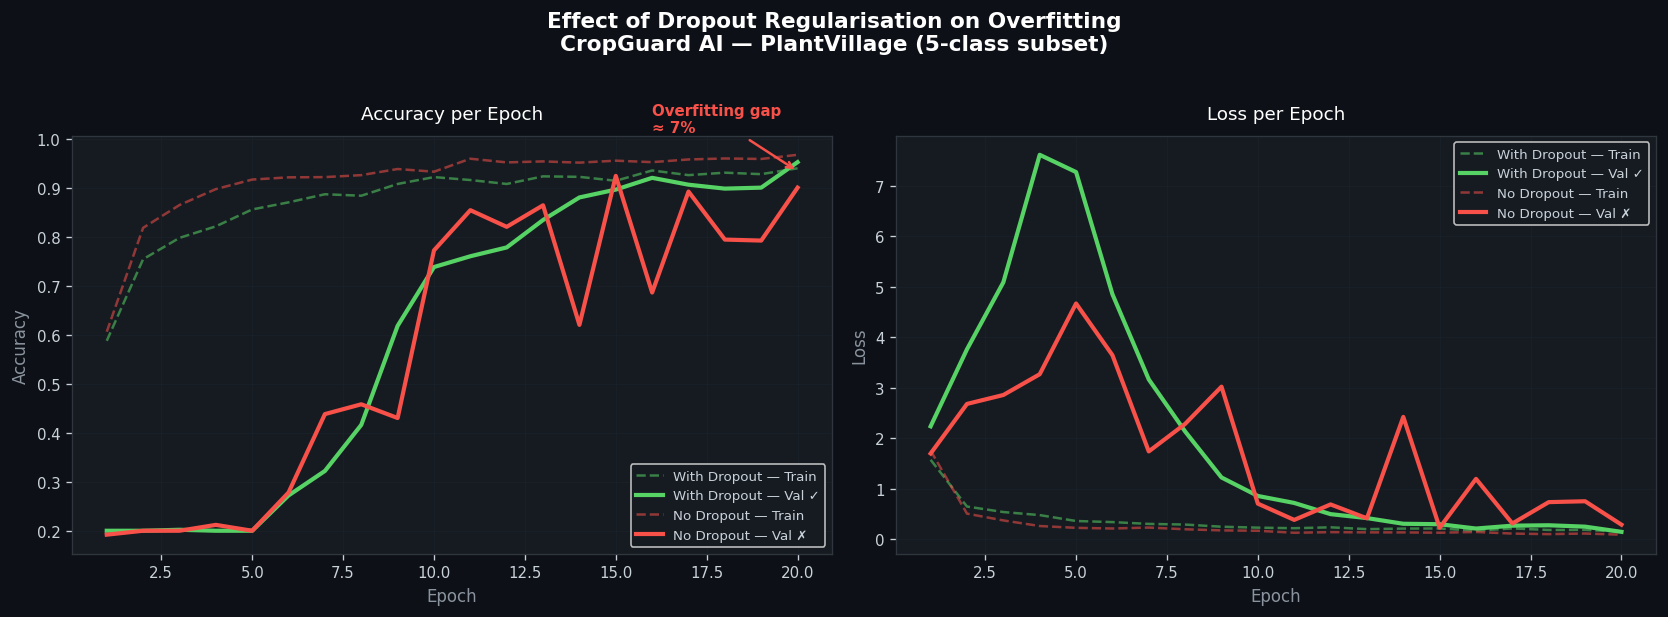

Comparison plot saved: /content/comparison_plot.png

── Per-Class Classification Report (WITH Dropout model) ──
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
              precision    recall  f1-score   support

Early blight       0.98      0.98      0.98       100
     healthy       0.99      0.98      0.98       100
Early blight       0.86      0.92      0.89       100
 Late blight       0.89      0.83      0.86       100
     healthy       0.99      1.00      1.00       100

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



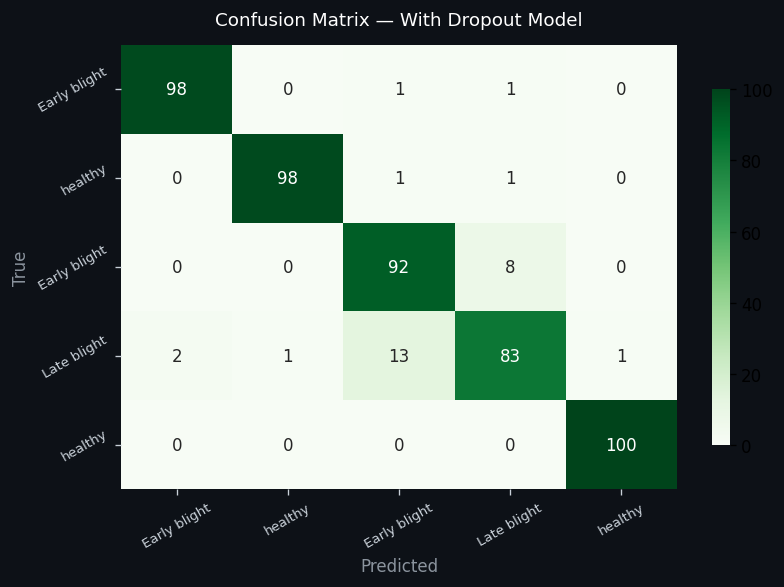

Confusion matrix saved: /content/confusion_matrix.png


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Effect of Dropout Regularisation on Overfitting\n'
             'CropGuard AI — PlantVillage (5-class subset)',
             fontsize=13, color='white', fontweight='bold', y=1.02)

GREEN, RED = '#56d364', '#f85149'

for ax in [ax1, ax2]:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9', labelsize=9)
    ax.spines[:].set_color('#30363d')
    ax.xaxis.label.set_color('#8b949e')
    ax.yaxis.label.set_color('#8b949e')
    ax.grid(alpha=0.15, color='#30363d')

e_wd = range(1, len(history_wd.history['accuracy']) + 1)
e_nd = range(1, len(history_nd.history['accuracy']) + 1)

ax1.plot(e_wd, history_wd.history['accuracy'],    color=GREEN, ls='--', lw=1.5, alpha=0.55, label='With Dropout — Train')
ax1.plot(e_wd, history_wd.history['val_accuracy'], color=GREEN, ls='-',  lw=2.5,             label='With Dropout — Val ✓')
ax1.plot(e_nd, history_nd.history['accuracy'],    color=RED,   ls='--', lw=1.5, alpha=0.55, label='No Dropout — Train')
ax1.plot(e_nd, history_nd.history['val_accuracy'], color=RED,   ls='-',  lw=2.5,             label='No Dropout — Val ✗')
ax1.set_title('Accuracy per Epoch', color='white', pad=10, fontsize=11)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=8, facecolor='#161b22', labelcolor='#c9d1d9', framealpha=0.9)

last_nd  = len(history_nd.history['accuracy'])
t_acc    = history_nd.history['accuracy'][-1]
v_acc    = history_nd.history['val_accuracy'][-1]
gap_annot = (t_acc - v_acc) * 100
ax1.annotate(
    f'Overfitting gap\n≈ {gap_annot:.0f}%',
    xy=(last_nd, (t_acc + v_acc)/2),
    xytext=(max(1, last_nd - 4), (t_acc + v_acc)/2 + 0.08),
    color=RED, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.5)
)

ax2.plot(e_wd, history_wd.history['loss'],     color=GREEN, ls='--', lw=1.5, alpha=0.55, label='With Dropout — Train')
ax2.plot(e_wd, history_wd.history['val_loss'],  color=GREEN, ls='-',  lw=2.5,             label='With Dropout — Val ✓')
ax2.plot(e_nd, history_nd.history['loss'],     color=RED,   ls='--', lw=1.5, alpha=0.55, label='No Dropout — Train')
ax2.plot(e_nd, history_nd.history['val_loss'],  color=RED,   ls='-',  lw=2.5,             label='No Dropout — Val ✗')
ax2.set_title('Loss per Epoch', color='white', pad=10, fontsize=11)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(fontsize=8, facecolor='#161b22', labelcolor='#c9d1d9', framealpha=0.9)

plt.tight_layout()
plt.savefig('/content/comparison_plot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Comparison plot saved: /content/comparison_plot.png')

print('\n── Per-Class Classification Report (WITH Dropout model) ──')
val_gen_eval, _ = make_generators(SUBSET_DIR)
val_gen_report = val_gen

val_gen.reset()
y_pred_probs = model_with_dropout.predict(val_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes[:len(y_pred)]

class_names = [CLASS_MAP[str(i)].split('___')[-1].replace('_', ' ') for i in range(NUM_CLASSES)]
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig2, ax = plt.subplots(figsize=(7, 5))
fig2.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Confusion Matrix — With Dropout Model', color='white', pad=12, fontsize=11)
ax.set_xlabel('Predicted', color='#8b949e')
ax.set_ylabel('True', color='#8b949e')
ax.tick_params(colors='#c9d1d9', labelsize=8, rotation=30)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Confusion matrix saved: /content/confusion_matrix.png')

In [46]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import json, io, base64
from PIL import Image

loaded_model = tf.keras.models.load_model('/content/model_with_dropout.keras')
with open('/content/class_indices.json') as f:
    CLASS_MAP_UI = json.load(f)

def parse_label(raw):
    parts   = raw.split('___')
    plant   = parts[0]
    disease = parts[1].replace('_', ' ').title() if len(parts) > 1 else 'Unknown'
    return plant, disease

def predict_from_bytes(img_bytes):
    img_pil  = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr      = np.array(img_pil, dtype=np.float32) / 255.0
    probs    = loaded_model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    top_idx  = int(np.argmax(probs))
    plant, disease = parse_label(CLASS_MAP_UI[str(top_idx)])
    return plant, disease, float(probs[top_idx]), probs

def to_b64(img_bytes):
    """Convert raw bytes to base64 string for inline <img> display."""
    return base64.b64encode(img_bytes).decode('utf-8')

# ── Styles ────────────────────────────────────────────────────────────────────
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&display=swap');
.cg-wrap * { font-family:'DM Sans','Segoe UI',sans-serif; box-sizing:border-box; }
.cg-header {
  background:linear-gradient(135deg,#1a472a,#2d6a4f);
  color:white; padding:22px 28px; border-radius:14px;
  margin-bottom:18px; box-shadow:0 4px 20px rgba(45,106,79,.25);
}
.cg-header h2 { margin:0; font-size:1.7rem; font-weight:600; letter-spacing:-.02em; }
.cg-header p  { margin:5px 0 0; opacity:.65; font-size:.8rem; font-weight:300; }
.cg-preview {
  border-radius:10px; overflow:hidden; margin-bottom:16px;
  border:1.5px solid #d0e8d8; max-width:340px;
}
.cg-preview img { width:100%; display:block; max-height:220px; object-fit:cover; }
.cg-preview-label {
  background:#f0faf3; padding:6px 12px; font-size:.75rem;
  color:#2d6a4f; font-weight:500; border-top:1px solid #d0e8d8;
}
.cg-card { border-radius:12px; padding:20px 22px; margin-top:16px; box-shadow:0 2px 12px rgba(0,0,0,.07); }
.cg-ok  { background:#f0faf3; border:1.5px solid #b7e2c8; }
.cg-bad { background:#fff5f5; border:1.5px solid #f5b8b2; }
.cg-status { font-size:1.05rem; font-weight:700; letter-spacing:.01em; margin-bottom:14px; display:flex; align-items:center; gap:8px; }
.cg-ok  .cg-status { color:#1e7e44; }
.cg-bad .cg-status { color:#c0392b; }
.cg-info-grid { display:grid; grid-template-columns:130px 1fr; gap:6px 0; font-size:.88rem; margin-bottom:18px; }
.cg-info-key   { color:#666; font-weight:500; }
.cg-info-value { color:#222; }
.cg-section-title { font-size:.75rem; font-weight:600; text-transform:uppercase; letter-spacing:.08em; color:#888; margin-bottom:12px; }
.cg-bar-row   { display:flex; align-items:center; gap:12px; margin-bottom:9px; }
.cg-bar-rank  { font-size:.75rem; color:#aaa; width:14px; text-align:right; flex-shrink:0; }
.cg-bar-name  { font-size:.82rem; color:#444; width:120px; flex-shrink:0; }
.cg-bar-track { flex:1; height:10px; background:#e8f4ec; border-radius:99px; overflow:hidden; }
.cg-bar-fill  { height:100%; border-radius:99px; }
.cg-bar-pct   { font-size:.8rem; font-weight:500; color:#555; width:42px; text-align:right; flex-shrink:0; }
.cg-tip { margin-top:16px; padding:11px 15px; background:#fffbea; border-left:4px solid #e9c46a; border-radius:0 8px 8px 0; font-size:.82rem; color:#7a5c00; line-height:1.5; }
.cg-divider { border:none; border-top:1px solid #e8ede8; margin:16px 0; }
</style>
<div class="cg-wrap">
  <div class="cg-header">
    <h2>🌾 CropGuard AI</h2>
    <p>CNN + Dropout Regularisation &nbsp;·&nbsp; PlantVillage Dataset &nbsp;·&nbsp; 5-Class Demo</p>
  </div>
</div>
"""))

# ── Widgets ───────────────────────────────────────────────────────────────────
upload_btn = widgets.FileUpload(
    accept='image/*', multiple=False,
    description='📷  Upload Leaf',
    layout=widgets.Layout(width='180px', height='42px'),
    style={'button_color':'#f0faf3', 'font_weight':'500'}
)
run_btn = widgets.Button(
    description='🔬  Run Diagnosis',
    layout=widgets.Layout(width='190px', height='42px'),
    style={'button_color':'#2d6a4f', 'font_weight':'600', 'text_color':'white'}
)
preview_out = widgets.Output()
result_out  = widgets.Output()

display(widgets.HBox(
    [upload_btn, run_btn],
    layout=widgets.Layout(gap='12px', padding='2px 0 10px', align_items='center')
))
display(preview_out)
display(result_out)

# ── Show preview as soon as image is uploaded ─────────────────────────────────
def on_upload(change):
    if not upload_btn.value:
        return
    img_bytes = list(upload_btn.value.values())[0]['content']
    fname     = list(upload_btn.value.keys())[0]
    b64       = to_b64(img_bytes)
    # detect mime type from filename
    ext  = fname.lower().split('.')[-1]
    mime = 'image/png' if ext == 'png' else 'image/jpeg'
    with preview_out:
        clear_output(wait=True)
        display(HTML(f"""
        <div class="cg-wrap">
          <div class="cg-preview">
            <img src="data:{mime};base64,{b64}" alt="Uploaded leaf">
            <div class="cg-preview-label">📎 {fname}</div>
          </div>
        </div>"""))

upload_btn.observe(on_upload, names='value')

# ── Prediction logic ──────────────────────────────────────────────────────────
TIPS = {
    'Early Blight': 'Apply copper-based fungicide. Remove infected lower leaves. Avoid overhead watering.',
    'Late Blight':  'Use mancozeb fungicide immediately. Destroy infected plants to stop spread.',
}

def make_chart(probs):
    sorted_idx = np.argsort(probs)          # ascending so highest is at top
    names  = [parse_label(CLASS_MAP_UI[str(i)])[1] for i in sorted_idx]
    values = probs[sorted_idx] * 100
    top    = int(np.argmax(probs))
    colors = ['#2d6a4f' if sorted_idx[i] == top else '#a8ddc0'
              for i in range(len(sorted_idx))]

    n = len(names)
    fig, ax = plt.subplots(figsize=(8, 0.7 * n + 1.2))  # height scales with number of bars
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    y_pos = range(n)
    bars = ax.barh(y_pos, values, color=colors, height=0.55, edgecolor='none')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(names, fontsize=10, color='#444')

    # percentage label to the right of each bar, never overlapping
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', ha='left',
            fontsize=9, color='#333', fontweight='500'
        )

    ax.set_xlabel('Confidence (%)', fontsize=9, color='#777')
    ax.set_xlim(0, 120)                     # extra room so % labels never clip
    ax.set_title('Prediction Confidence per Class',
                 fontsize=10, color='#222', pad=12, fontweight='500')
    ax.tick_params(axis='x', labelsize=9, colors='#777')
    ax.tick_params(axis='y', length=0)      # hide y tick marks
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#ddd')
    ax.grid(axis='x', alpha=0.25, color='#ccc', linestyle='--')
    plt.tight_layout(pad=1.2)
    return fig

def on_run(b):
    if not upload_btn.value:
        with result_out:
            clear_output(wait=True)
            display(HTML('<p style="color:#c0392b;font-size:.88rem;">⚠️ Please upload a leaf image first.</p>'))
        return

    img_bytes = list(upload_btn.value.values())[0]['content']
    plant, disease, conf, probs = predict_from_bytes(img_bytes)
    is_healthy = 'healthy' in disease.lower()
    css  = 'cg-ok'  if is_healthy else 'cg-bad'
    icon = '✅'      if is_healthy else '⚠️'
    stat = 'HEALTHY PLANT' if is_healthy else 'DISEASE DETECTED'
    tip  = (f'<div class="cg-tip">💡 {TIPS[disease]}</div>'
            if not is_healthy and disease in TIPS else '')

    bars_html = '<div class="cg-section-title">All Class Probabilities</div>'
    for rank, idx in enumerate(np.argsort(probs)[::-1], 1):
        _, dis = parse_label(CLASS_MAP_UI[str(idx)])
        pct    = probs[idx] * 100
        color  = '#2d6a4f' if idx == int(np.argmax(probs)) else '#a8ddc0'
        bars_html += f"""
        <div class="cg-bar-row">
          <span class="cg-bar-rank">{rank}.</span>
          <span class="cg-bar-name">{dis}</span>
          <div class="cg-bar-track">
            <div class="cg-bar-fill" style="width:{pct:.1f}%;background:{color}"></div>
          </div>
          <span class="cg-bar-pct">{pct:.1f}%</span>
        </div>"""

    with result_out:
        clear_output(wait=True)
        display(HTML(f"""
        <div class="cg-wrap">
          <div class="cg-card {css}">
            <div class="cg-status">{icon} {stat}</div>
            <div class="cg-info-grid">
              <span class="cg-info-key">🌱 Plant</span>
              <span class="cg-info-value">{plant}</span>
              <span class="cg-info-key">🔬 Diagnosis</span>
              <span class="cg-info-value">{disease}</span>
              <span class="cg-info-key">📊 Confidence</span>
              <span class="cg-info-value">{conf*100:.1f}%</span>
              <span class="cg-info-key">📐 Model</span>
              <span class="cg-info-value">CNN + Dropout (p=0.5)</span>
            </div>
            <hr class="cg-divider">
            {bars_html}
            {tip}
          </div>
        </div>"""))
        fig = make_chart(probs)
        plt.show()

run_btn.on_click(on_run)

Output()

Output()